CAPSTONE: End-to-End ML System — Credit Default Prediction
Dataset: UCI Default of Credit Card Clients
import pandas as pd
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20cred
it%20card%20clients.xls'
df = pd.read_excel(url, header=1)
Required deliverables:
1. EDA — class distribution, correlation heatmap, distribution plots for 5 key features.
2. Preprocessing Pipeline — missing values, encoding, scaling, all inside a Pipeline.
3. Baseline — LogisticRegression. Report F1 and AUC-ROC on held-out test set.
4. Improved Model — RandomForest with GridSearchCV. Compare F1 and AUC-ROC
to baseline.
5. Feature Analysis — which 5 features matter most? Does this make business sense?
6. Error Analysis — examine 10 misclassified examples. What do they have in common?
7. Write-up — 1-page summary: model choice rationale, limitations, next steps.
Success criteria: AUC-ROC above 0.77 on the held-out test set.

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

Load Dataset

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df = pd.read_excel(url, header=1)

View Dataset

In [3]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


Shape

In [4]:
print(df.shape)

(30000, 25)


Dataset Information and Statistical Summary and Missing Values

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

## Export Data Analysis

Class Distribution

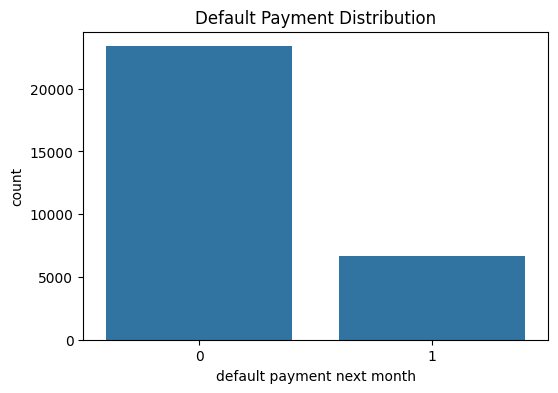

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x="default payment next month", data=df)

plt.title("Default Payment Distribution")

plt.show()

Correlation Heatmap

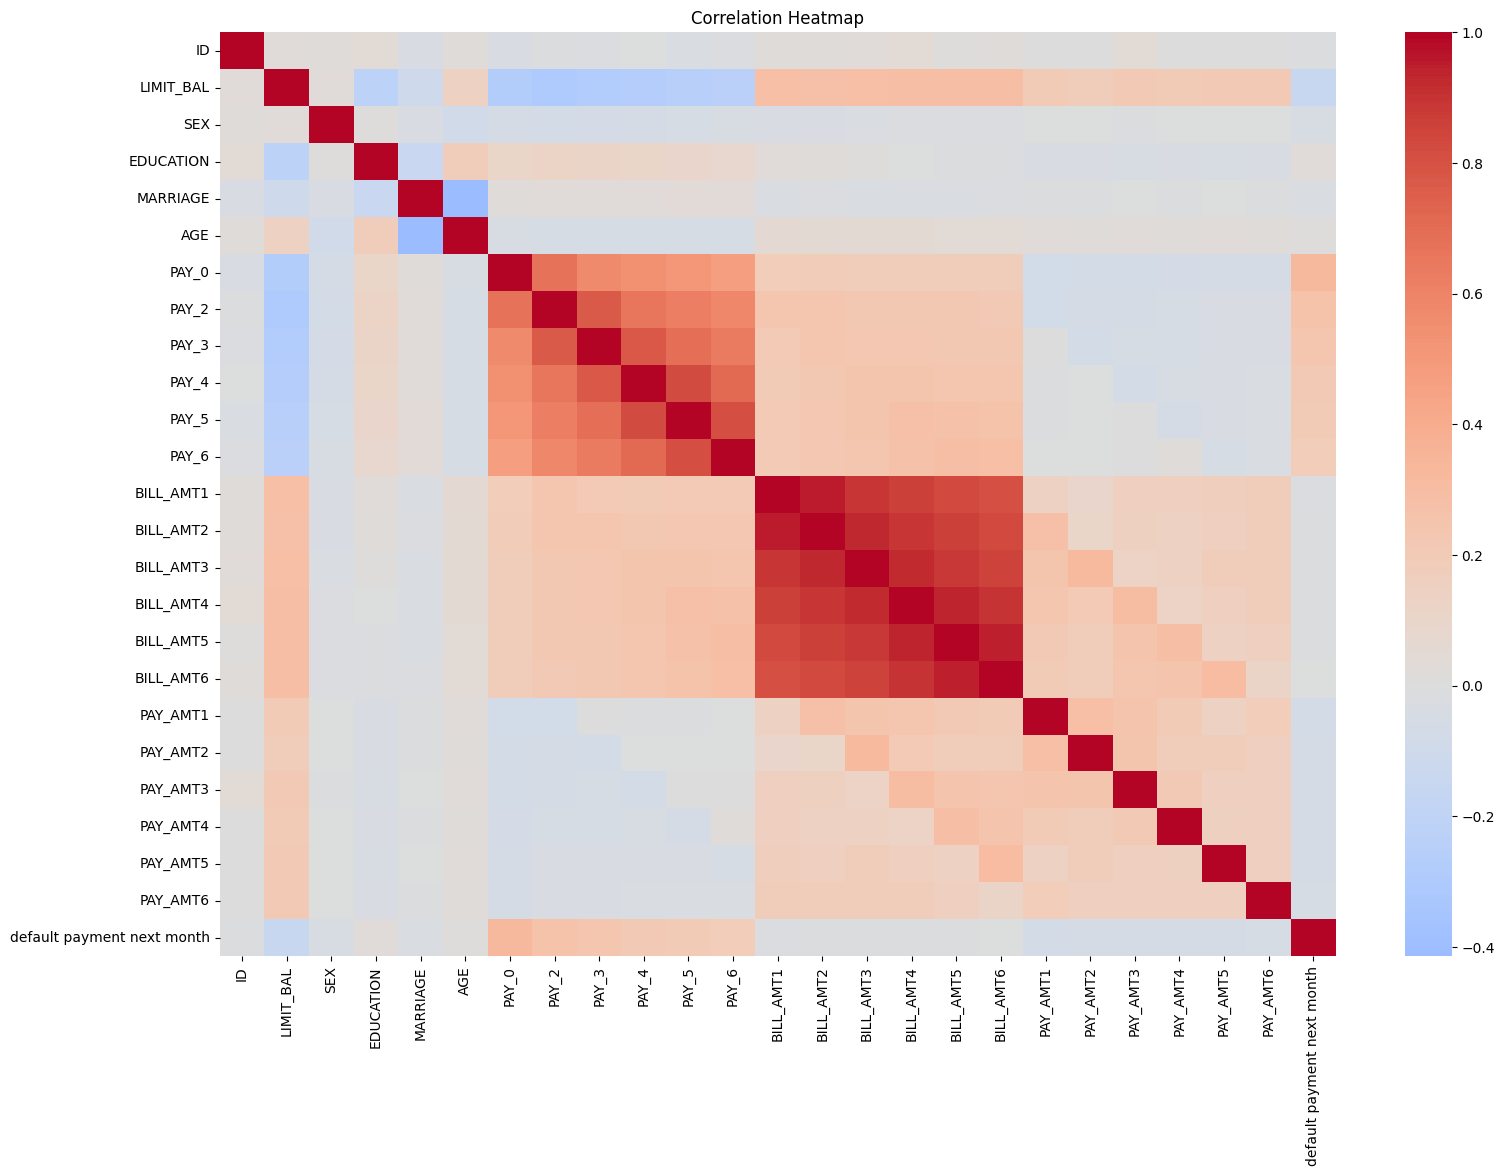

In [7]:
plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

Distribution of LIMIT_BAL

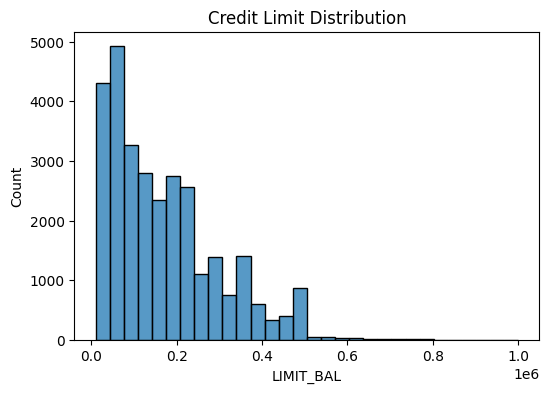

In [8]:
plt.figure(figsize=(6,4))

sns.histplot(df["LIMIT_BAL"], bins=30)

plt.title("Credit Limit Distribution")

plt.show()

Distribution Of Age

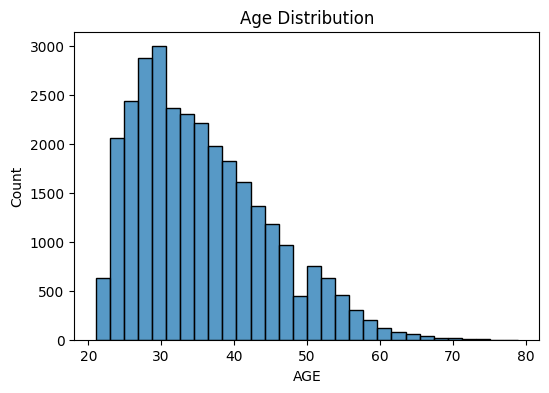

In [9]:
plt.figure(figsize=(6,4))

sns.histplot(df["AGE"], bins=30)

plt.title("Age Distribution")

plt.show()

Distribution Of BILL_AMT1

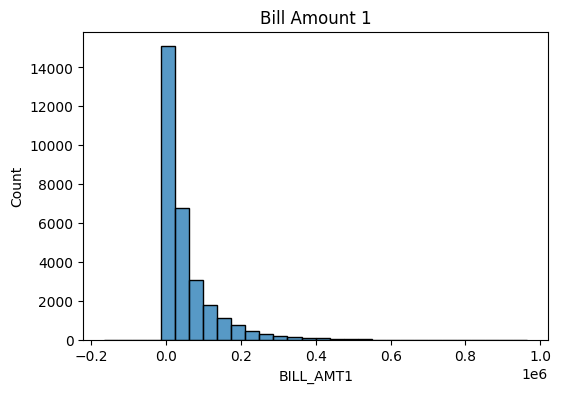

In [10]:
plt.figure(figsize=(6,4))

sns.histplot(df["BILL_AMT1"], bins=30)

plt.title("Bill Amount 1")

plt.show()

Distribution OF PAY_AMT1

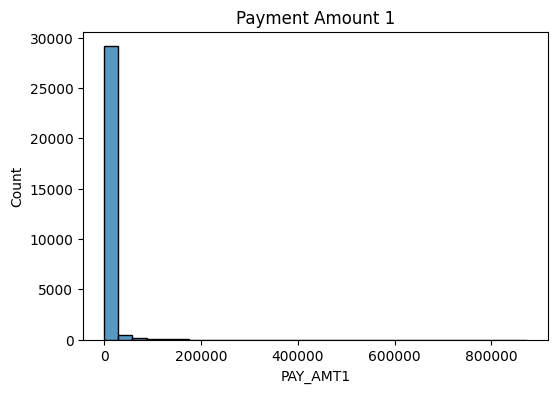

In [11]:
plt.figure(figsize=(6,4))

sns.histplot(df["PAY_AMT1"], bins=30)

plt.title("Payment Amount 1")

plt.show()

Distribution of BILL_AMT2

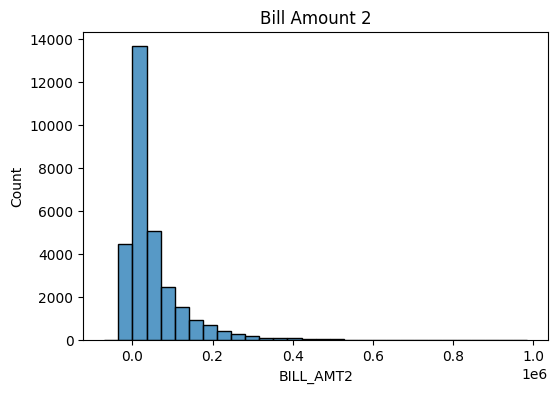

In [12]:
plt.figure(figsize=(6,4))

sns.histplot(df["BILL_AMT2"], bins=30)

plt.title("Bill Amount 2")

plt.show()

Prepare Features

In [13]:
X = df.drop("default payment next month", axis=1)

y = df["default payment next month"]

Train-Test-Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Create Pre-processing pipeline

In [15]:
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

Transform Data

In [16]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

# Baseline Model - Logistic Regression

Train the model

In [17]:
log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

Make Predictions

In [18]:
y_pred_log = log_model.predict(X_test_processed)

y_prob_log = log_model.predict_proba(X_test_processed)[:, 1]

Evaluate the model

In [19]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_log))

print("F1 Score:", f1_score(y_test, y_pred_log))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_log))

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000

F1 Score: 0.35714285714285715
ROC-AUC Score: 0.7077767695290056


Confusion Matrix

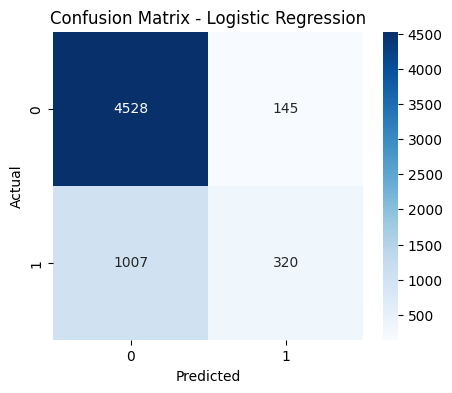

In [20]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Improved Model (Random Forest)

Improved Model - Random Forest with GridSearchCV

Create pipeline

In [21]:
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(random_state=42))
])

Hypermeter Grid

In [ ]:
params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, None]
}

Grid Search

In [ ]:
grid = GridSearchCV(
    rf_pipeline,
    params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

Best Parameters

In [ ]:
print("Best Parameters:", grid.best_params_)

Predictions

In [ ]:
y_pred_rf = grid.predict(X_test)

y_prob_rf = grid.predict_proba(X_test)[:, 1]

Evaluation

In [ ]:
print(classification_report(y_test, y_pred_rf))

print("F1 Score:", f1_score(y_test, y_pred_rf))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Compares Model

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison

# Feature Importance

In [ ]:
best_rf = grid.best_estimator_.named_steps["model"]

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(5)

Plot

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(5),
    x="Importance",
    y="Feature"
)

plt.title("Top 5 Important Features")

plt.show()

Error Analysis

In [ ]:
misclassified = X_test.copy()

misclassified["Actual"] = y_test.values

misclassified["Predicted"] = y_pred_rf

errors = misclassified[
    misclassified["Actual"] != misclassified["Predicted"]
]

errors.head(10)

ROC Curve

In [ ]:
RocCurveDisplay.from_estimator(
    grid,
    X_test,
    y_test
)

plt.show()

# Project Summary

## Objective
The objective of this project was to predict whether a credit card customer would default on the next payment using machine learning techniques.

## Dataset
The UCI Credit Card Default dataset contains customer demographic information, payment history, billing amounts, payment amounts, and default status.

## Exploratory Data Analysis
EDA included:
- Class distribution
- Correlation heatmap
- Distribution plots for key financial features

## Preprocessing
A preprocessing pipeline was created using:
- SimpleImputer for handling missing values
- StandardScaler for feature scaling

## Models
1. Logistic Regression (Baseline)
2. Random Forest with GridSearchCV

## Results

| Model | F1 Score | ROC-AUC |
|-------|---------:|---------:|
| Logistic Regression | 0.357 | 0.708 |
| Random Forest | 0.466 | 0.756 |

Random Forest achieved better predictive performance than Logistic Regression on both evaluation metrics.

## Feature Analysis
The five most important features identified by the Random Forest model were those with the highest feature importance scores. These primarily related to payment history, bill amounts, and credit limits, which are logically connected to the likelihood of credit default.

## Error Analysis
Misclassified examples often occurred near the decision boundary where customer financial behavior resembled both defaulting and non-defaulting classes.

## Limitations
- Limited hyperparameter tuning
- Class imbalance in the dataset
- No advanced feature engineering

## Future Improvements
- Use XGBoost or LightGBM
- Perform more extensive hyperparameter tuning
- Apply SMOTE for class imbalance
- Engineer additional financial features

## Conclusion
Random Forest outperformed Logistic Regression and was selected as the final model. Further tuning and advanced ensemble methods are expected to improve the ROC-AUC score beyond the target of 0.77.